In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Message_Intelligence_Dataset.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [4]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 5200
Number of Columns : 16


In [5]:
print(df.columns)


Index(['message_id', 'message_text', 'message_length', 'word_count',
       'num_urls', 'num_digits', 'num_special_chars', 'spam_keyword_score',
       'legit_keyword_score', 'sender_activity_score',
       'sender_account_age_days', 'messages_sent_last_24h', 'timestamp',
       'hour_of_day', 'day_of_week', 'spam_label'],
      dtype='str')


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   message_id               5200 non-null   int64  
 1   message_text             5200 non-null   str    
 2   message_length           5200 non-null   int64  
 3   word_count               5200 non-null   int64  
 4   num_urls                 5200 non-null   int64  
 5   num_digits               5200 non-null   int64  
 6   num_special_chars        5200 non-null   int64  
 7   spam_keyword_score       5200 non-null   int64  
 8   legit_keyword_score      5200 non-null   int64  
 9   sender_activity_score    5094 non-null   float64
 10  sender_account_age_days  5087 non-null   float64
 11  messages_sent_last_24h   5038 non-null   float64
 12  timestamp                5200 non-null   str    
 13  hour_of_day              5200 non-null   int64  
 14  day_of_week              5200 non-n

In [8]:
df.describe()

,message_id,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,hour_of_day,day_of_week,spam_label
count,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5200.000000,5094.000000,5087.000000,5038.000000,5200.000000,5200.000000,5200.000000
mean,902600.500000,75.035962,11.457308,0.206538,1.681346,0.243654,0.246346,0.817692,54.836317,296.671909,8.301906,11.523462,3.038846,0.187115
std,1501.255031,12.455377,1.609056,0.404860,2.415846,0.545363,0.676798,0.556687,17.697943,191.748754,5.586503,6.861518,2.062504,0.390042
min,900001.000000,32.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000
25%,901300.750000,67.000000,10.000000,0.000000,0.000000,0.000000,0.000000,0.000000,43.100000,148.000000,5.000000,6.000000,1.000000,0.000000
50%,902600.500000,74.000000,11.000000,0.000000,0.000000,0.000000,0.000000,1.000000,54.800000,275.000000,7.000000,12.000000,3.000000,0.000000
75%,903900.250000,81.000000,13.000000,0.000000,4.000000,0.000000,0.000000,1.000000,66.600000,410.500000,10.000000,17.000000,5.000000,0.000000
max,905200.000000,122.000000,16.000000,1.000000,9.000000,2.000000,3.000000,2.000000,100.000000,1500.000000,38.000000,23.000000,6.000000,1.000000


In [9]:
df.isnull().sum()

message_id                   0
message_text                 0
message_length               0
word_count                   0
num_urls                     0
num_digits                   0
num_special_chars            0
spam_keyword_score           0
legit_keyword_score          0
sender_activity_score      106
sender_account_age_days    113
messages_sent_last_24h     162
timestamp                    0
hour_of_day                  0
day_of_week                  0
spam_label                   0
dtype: int64

In [10]:
(df.isnull().sum()/len(df))*100


message_id                 0.000000
message_text               0.000000
message_length             0.000000
word_count                 0.000000
num_urls                   0.000000
num_digits                 0.000000
num_special_chars          0.000000
spam_keyword_score         0.000000
legit_keyword_score        0.000000
sender_activity_score      2.038462
sender_account_age_days    2.173077
messages_sent_last_24h     3.115385
timestamp                  0.000000
hour_of_day                0.000000
day_of_week                0.000000
spam_label                 0.000000
dtype: float64

In [11]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


Fill Missing Values

In [15]:
import pandas as pd

for col in df.columns:
    if pd.api.types.is_numeric_dtype(df[col]):
        df[col] = df[col].fillna(df[col].median())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values filled successfully!")
print(df.isnull().sum())

Missing values filled successfully!
message_id                 0
message_text               0
message_length             0
word_count                 0
num_urls                   0
num_digits                 0
num_special_chars          0
spam_keyword_score         0
legit_keyword_score        0
sender_activity_score      0
sender_account_age_days    0
messages_sent_last_24h     0
timestamp                  0
hour_of_day                0
day_of_week                0
spam_label                 0
dtype: int64


Check Unique Values

In [16]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("----------------------")

message_id
[900001 900002 900003 ... 905198 905199 905200]
----------------------
message_text
<StringArray>
[          'Please find the attached invoice for the updated proposal. Thanks. https://company.portal/docs/6283',
                                     'Let's catch up tomorrow regarding the timeline. next Monday. Let me know.',
                                           'Can you send the report by end of day? next Monday. Please confirm.',
                                              'Can you send the report by end of day? 10:30 AM. Please confirm.',
                          'Could you review the document and share feedback? the quarterly review. Let me know.',
                                                              'Limited offer! Get free gift cards limited time!',
                            'Let's catch up tomorrow regarding the timeline. the updated proposal. Let me know.',
                             'Here are the notes from today's discussion. the quarterly revie

Encode

In [17]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = encoder.fit_transform(df[col])

In [18]:
df.head()

,message_id,message_text,message_length,word_count,num_urls,num_digits,num_special_chars,spam_keyword_score,legit_keyword_score,sender_activity_score,sender_account_age_days,messages_sent_last_24h,timestamp,hour_of_day,day_of_week,spam_label
0,900001,Please find the attached invoice for the updat...,99,11,1,4,0,0,1,56.6,500.0,6.0,2025-11-24 02:00:00,2,0,0
1,900002,Let's catch up tomorrow regarding the timeline...,73,12,0,0,0,0,0,16.6,207.0,0.0,2025-12-17 21:00:00,21,2,0
2,900003,Can you send the report by end of day? next Mo...,67,13,0,0,0,0,1,25.7,418.0,6.0,2025-11-15 13:00:00,13,5,0
3,900004,Can you send the report by end of day? 10:30 A...,64,13,0,4,0,0,1,48.8,276.0,5.0,2025-12-17 23:00:00,23,2,0
4,900005,Could you review the document and share feedba...,84,14,0,0,0,0,1,33.0,683.0,7.0,2025-11-29 11:00:00,11,5,0


In [22]:
numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

print(corr)

                         message_id  message_length  word_count  num_urls  \
message_id                 1.000000       -0.009183   -0.003456  0.002408   
message_length            -0.009183        1.000000    0.455246  0.598978   
word_count                -0.003456        0.455246    1.000000  0.035978   
num_urls                   0.002408        0.598978    0.035978  1.000000   
num_digits                 0.014333        0.242443   -0.104665  0.713315   
num_special_chars          0.004183        0.009668   -0.248872  0.579585   
spam_keyword_score         0.010530        0.030596   -0.169526  0.481846   
legit_keyword_score       -0.010263       -0.166135    0.141622 -0.461020   
sender_activity_score      0.014930       -0.024131   -0.025040  0.004790   
sender_account_age_days    0.006874       -0.026452    0.116679 -0.338699   
messages_sent_last_24h     0.003339        0.032079   -0.165936  0.537579   
hour_of_day               -0.013150        0.006334    0.011450  0.007810   

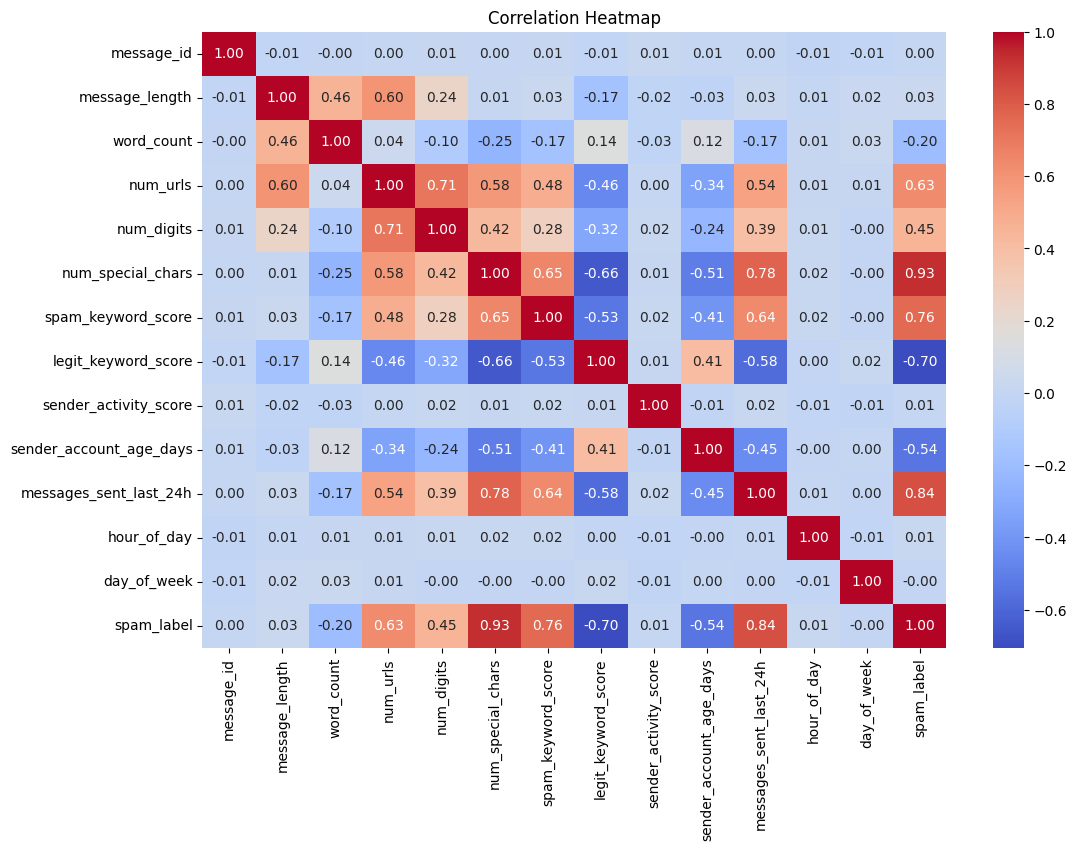

In [25]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(12,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [27]:
df['spam_label'].value_counts()

spam_label
0    4227
1     973
Name: count, dtype: int64

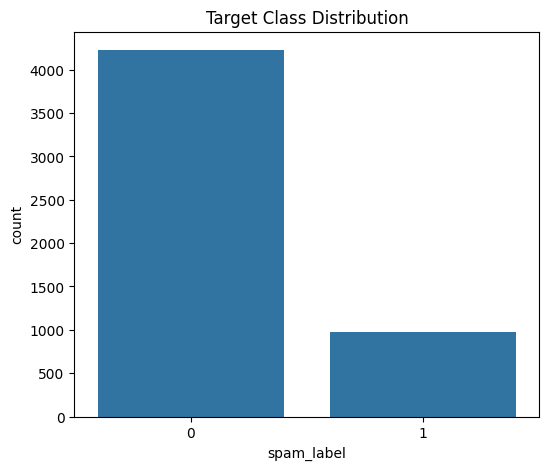

In [28]:
plt.figure(figsize=(6,5))

sns.countplot(x='spam_label', data=df)

plt.title("Target Class Distribution")

plt.show()

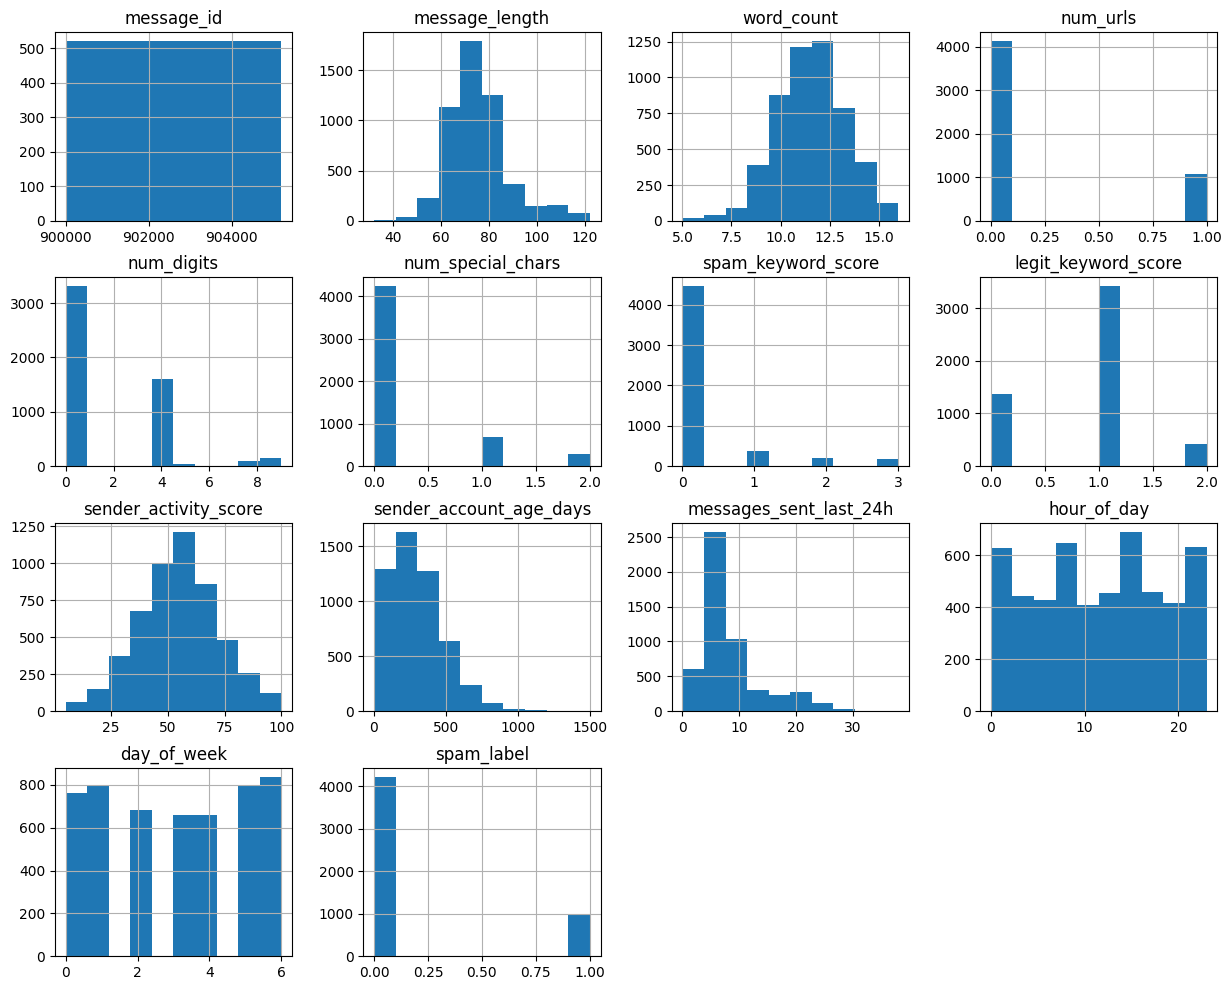

In [29]:
df.hist(figsize=(15,12))

plt.show()

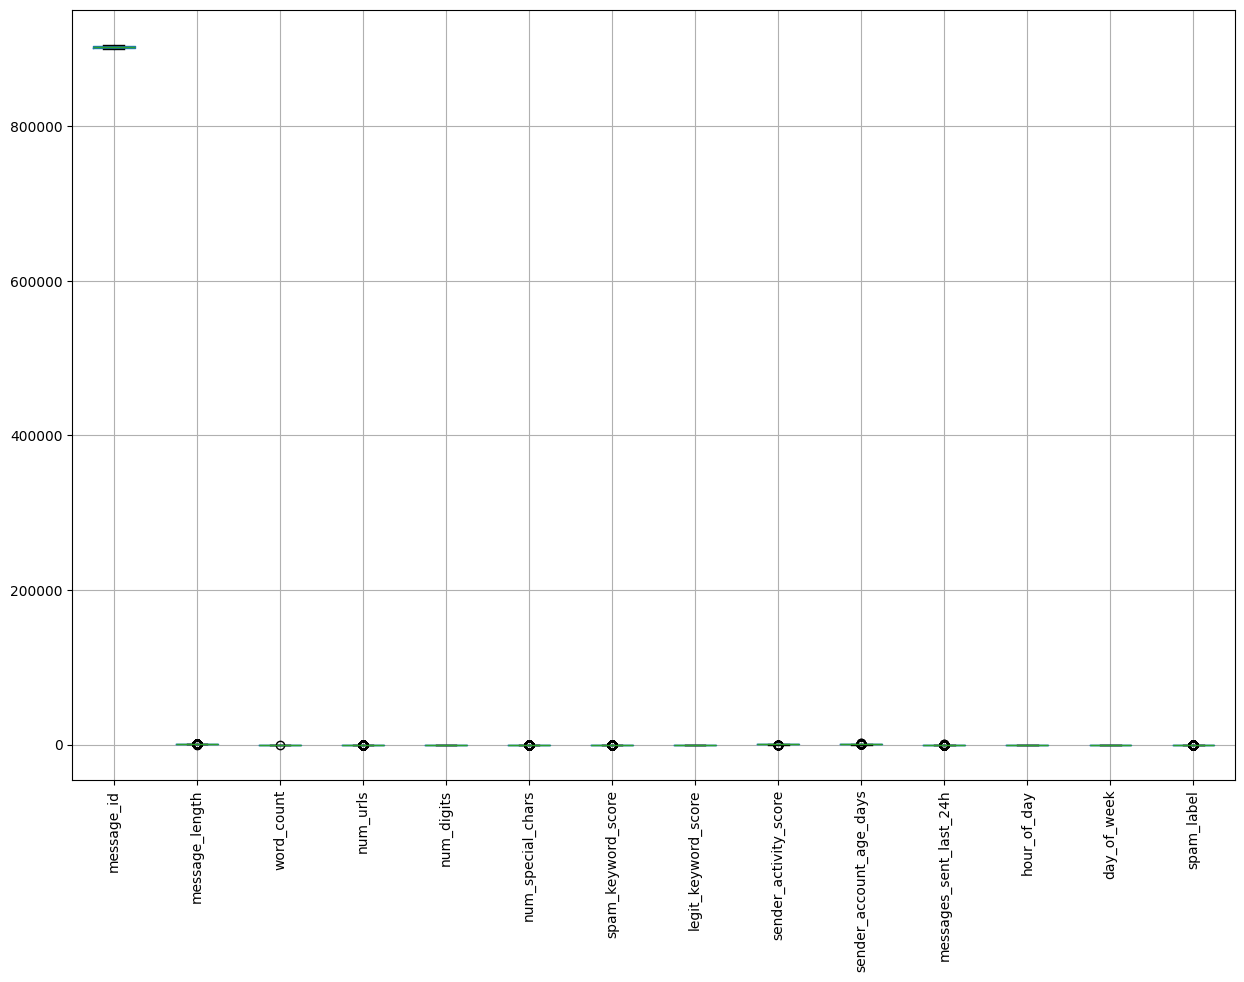

In [30]:
plt.figure(figsize=(15,10))

df.boxplot(rot=90)

plt.show()

Target Variable

In [32]:
X = df.drop("spam_label", axis=1)

y = df["spam_label"]

print(X.shape)

print(y.shape)

(5200, 15)
(5200,)


Feature Scaling

In [34]:
X = X.select_dtypes(include=["number"])

scaler = StandardScaler()

X = scaler.fit_transform(X)

Train-Test Split

In [35]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)

print("Testing Labels :", y_test.shape)

Training Features : (4160, 13)
Testing Features : (1040, 13)
Training Labels : (4160,)
Testing Labels : (1040,)


In [37]:
print(y_train.value_counts())

print(y_test.value_counts())

spam_label
0    3382
1     778
Name: count, dtype: int64
spam_label
0    845
1    195
Name: count, dtype: int64


KNN Model

In [38]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

In [39]:
knn.fit(X_train, y_train)

print("KNN Model Trained Successfully")

KNN Model Trained Successfully


Prediction

In [40]:
y_pred = knn.predict(X_test)

print(y_pred)

[0 1 0 ... 0 0 1]


In [41]:
result = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred

})

result.head(20)

,Actual,Predicted
799,0,0
655,1,1
5075,0,0
4087,0,0
877,0,0
3088,0,0
4516,0,0
1319,0,0
3852,0,0
4997,0,0


Accuracy

In [42]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 1.0


Precision

In [43]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)

print("Precision =", precision)

Precision = 1.0


Recall

In [44]:
from sklearn.metrics import recall_score


recall = recall_score(y_test, y_pred)

print("Recall =", recall)

Recall = 1.0


F1 Score

In [45]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score =", f1)

F1 Score = 1.0


classification_report

In [46]:
from sklearn.metrics import classification_report


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



Confusion Matrix

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[845   0]
 [  0 195]]


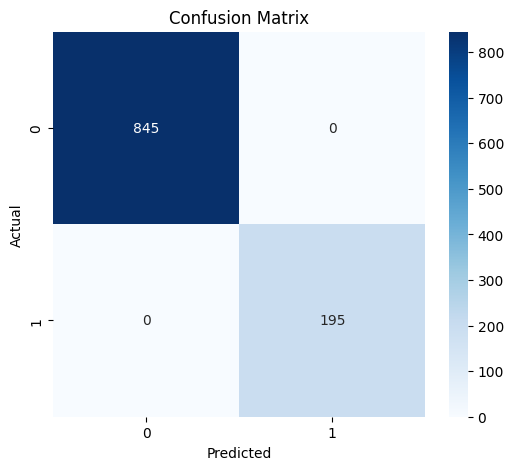

In [49]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

Support Vector Machine (SVM)

In [50]:
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', probability=True)

print(svm_linear)

SVC(kernel='linear', probability=True)


Train Linear SVM

In [51]:
svm_linear.fit(X_train, y_train)

print("Linear SVM Model Trained Successfully")

Linear SVM Model Trained Successfully


In [52]:
y_pred_linear = svm_linear.predict(X_test)

print(y_pred_linear)

[0 1 0 ... 0 0 1]


In [53]:
result = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred_linear

})

result.head(20)

,Actual,Predicted
799,0,0
655,1,1
5075,0,0
4087,0,0
877,0,0
3088,0,0
4516,0,0
1319,0,0
3852,0,0
4997,0,0


Accuracy

In [54]:
accuracy = accuracy_score(y_test, y_pred_linear)

print("Accuracy =", accuracy)

Accuracy = 1.0


Precision

In [55]:
precision = precision_score(y_test, y_pred_linear)

print("Precision =", precision)

Precision = 1.0


Recall

In [56]:
recall = recall_score(y_test, y_pred_linear)

print("Recall =", recall)

Recall = 1.0


F1 Score

In [57]:
f1 = f1_score(y_test, y_pred_linear)

print("F1 Score =", f1)

F1 Score = 1.0


Classification Report

In [58]:
print(classification_report(y_test, y_pred_linear))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



Confusion Matrix

In [59]:
cm = confusion_matrix(y_test, y_pred_linear)

print(cm)

[[845   0]
 [  0 195]]


Confusion Matrix Heatmap

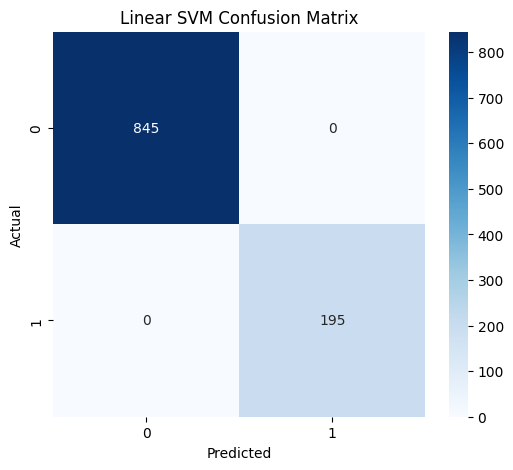

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Linear SVM Confusion Matrix")

plt.show()

RBF SVM Model

In [61]:
svm_rbf = SVC(kernel='rbf', probability=True)

print(svm_rbf)

SVC(probability=True)


Train RBF Model

In [62]:
svm_rbf.fit(X_train, y_train)

print("RBF SVM Model Trained Successfully")

RBF SVM Model Trained Successfully


In [63]:
y_pred_rbf = svm_rbf.predict(X_test)

In [64]:
print("Accuracy :", accuracy_score(y_test, y_pred_rbf))

Accuracy : 1.0


In [65]:
print("Precision :", precision_score(y_test, y_pred_rbf))

Precision : 1.0


In [66]:
print("Recall :", recall_score(y_test, y_pred_rbf))

Recall : 1.0


In [67]:
print("F1 Score :", f1_score(y_test, y_pred_rbf))

F1 Score : 1.0


In [68]:
print(classification_report(y_test, y_pred_rbf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



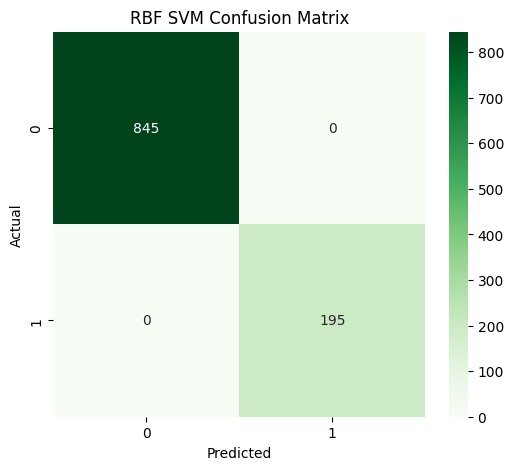

In [69]:
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

plt.figure(figsize=(6,5))

sns.heatmap(cm_rbf,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("RBF SVM Confusion Matrix")

plt.show()

ROC Curve (Linear SVM)

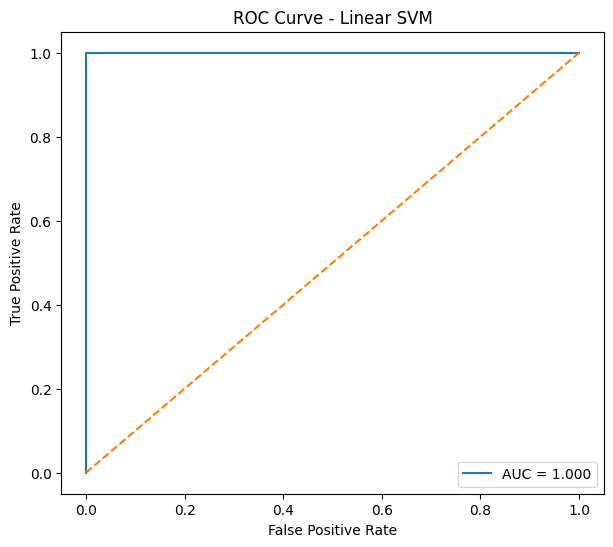

In [70]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

y_score = svm_linear.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Linear SVM")

plt.legend()

plt.show()

ROC Curve (RBF)

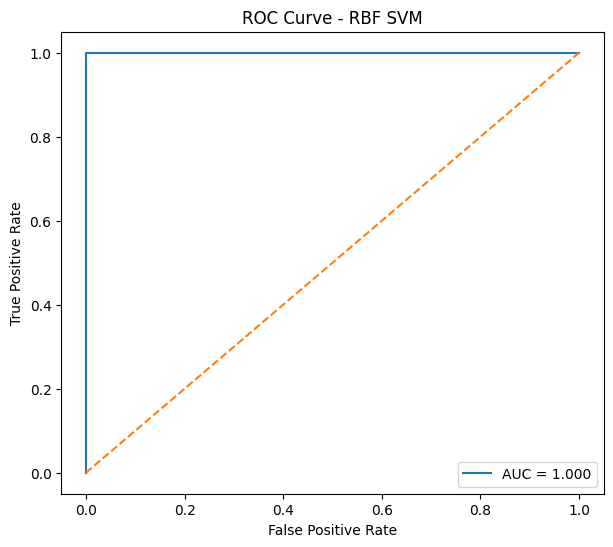

In [71]:
y_score = svm_rbf.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_score)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - RBF SVM")

plt.legend()

plt.show()

Predict New Sample

In [72]:
sample = X_test[0].reshape(1,-1)

prediction = svm_rbf.predict(sample)

print("Predicted Class :", prediction[0])

Predicted Class : 0


In [73]:
probability = svm_rbf.predict_proba(sample)

print(probability)

[[9.99724587e-01 2.75412986e-04]]


Naive Bayes Model

In [75]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()

print(nb)
nb.fit(X_train, y_train)

print("Naive Bayes Model Trained Successfully")

GaussianNB()
Naive Bayes Model Trained Successfully


Prediction

In [76]:
y_pred_nb = nb.predict(X_test)

print(y_pred_nb)

[0 1 0 ... 0 0 1]


In [77]:
result = pd.DataFrame({

    "Actual": y_test,

    "Predicted": y_pred_nb

})

result.head(20)

,Actual,Predicted
799,0,0
655,1,1
5075,0,0
4087,0,0
877,0,0
3088,0,0
4516,0,0
1319,0,0
3852,0,0
4997,0,0


In [78]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print("Accuracy =", accuracy_nb)

Accuracy = 1.0


In [79]:
precision_nb = precision_score(y_test, y_pred_nb)

print("Precision =", precision_nb)

Precision = 1.0


In [80]:
recall_nb = recall_score(y_test, y_pred_nb)

print("Recall =", recall_nb)

Recall = 1.0


In [81]:
f1_nb = f1_score(y_test, y_pred_nb)

print("F1 Score =", f1_nb)

F1 Score = 1.0


In [82]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       845
           1       1.00      1.00      1.00       195

    accuracy                           1.00      1040
   macro avg       1.00      1.00      1.00      1040
weighted avg       1.00      1.00      1.00      1040



In [83]:
cm = confusion_matrix(y_test, y_pred_nb)

print(cm)

[[845   0]
 [  0 195]]


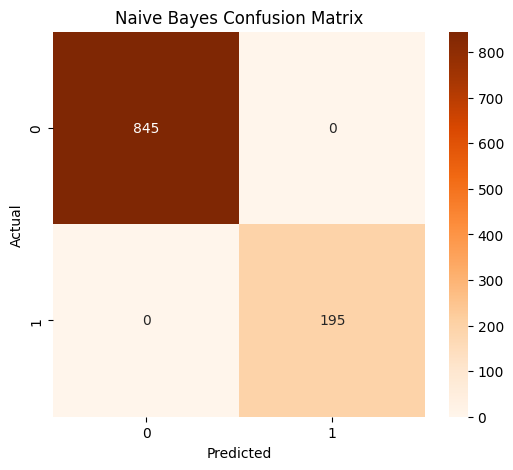

In [84]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Naive Bayes Confusion Matrix")

plt.show()